# **News Category**

---

News headline categorization with fine-tuned DistilBERT, BiLSTM, Logistic Regression, and Naive Bayes.

## **Comparison**

---

Aggregates the four models' saved results into a single view: the best each model achieves, how they compare across field configurations, and which categories separate them.

Inputs (under `results/<model>/`):

- `scores.json`: test metrics per field configuration

- `best_params.json`: winning settings per field configuration

### **Setup**

---

#### **Config**


In [1]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from news_category.data import CONFIGS
from news_category.display import show

MODELS = ["Naive Bayes", "Logistic Regression", "BiLSTM", "DistilBERT"]
METRIC = "f1"

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 18


def slug(model: str) -> str:
  return model.lower().replace(" ", "_")

#### **Load**


In [2]:
DIR_IN = Path("results")


def load_scores(model: str) -> pd.Series:
  with open(DIR_IN / model / "scores.json") as f:
    scores = json.load(f)
  return pd.Series({config: scores[config][METRIC] for config in scores})


df_scores = pd.DataFrame({model: load_scores(slug(model)) for model in MODELS}).loc[list(CONFIGS)]
show("Macro F1 by Configuration", df_scores)

── Macro F1 by Configuration ───────────────


,Naive Bayes,Logistic Regression,BiLSTM,DistilBERT
headline,0.492682,0.517410,0.514958,0.587405
short_description,0.341444,0.351042,0.362734,0.418697
authors,0.624543,0.623494,0.563957,0.581311
headline+short_description,0.535943,0.563797,0.551348,0.639764
headline+authors,0.668027,0.706472,0.669836,0.737387
short_description+authors,0.604056,0.619889,0.560357,0.646505
headline+short_description+authors,0.695192,0.712782,0.668308,0.761718


### **Comparison**

---

#### **Best Model**

The strongest macro-F1 each model reaches across all configurations, and the configuration that achieves it.


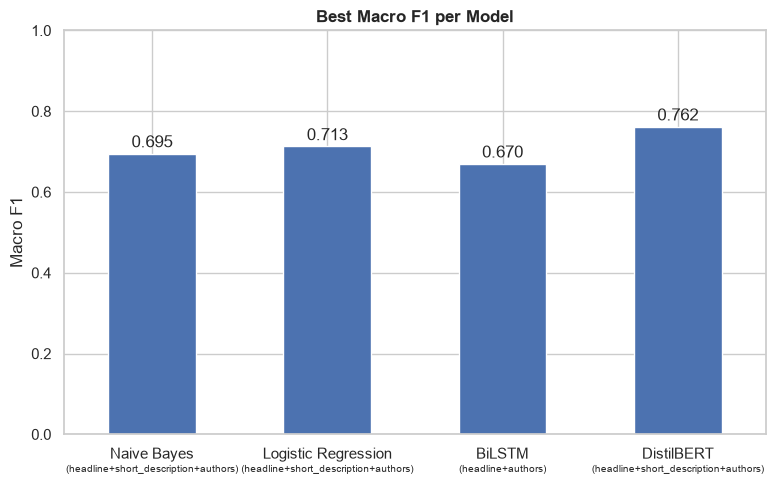

In [3]:
best = pd.DataFrame(
  {
    "score": df_scores.max(),
    "configuration": df_scores.idxmax(),
  }
)

fig, ax = plt.subplots(figsize=(8, 5))
best["score"].plot.bar(ax=ax, ylim=(0, 1), rot=0, title="Best Macro F1 per Model", ylabel="Macro F1")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2)
for x, model in enumerate(best.index):
  ax.annotate(
    f"({best.loc[model, 'configuration']})", (x, 0), (0, -22), textcoords="offset points", ha="center", va="top", fontsize=7
  )
plt.tight_layout()
plt.show()

#### **By Configuration**

Every model's macro-F1 across the seven field configurations, showing where added fields help or distract.


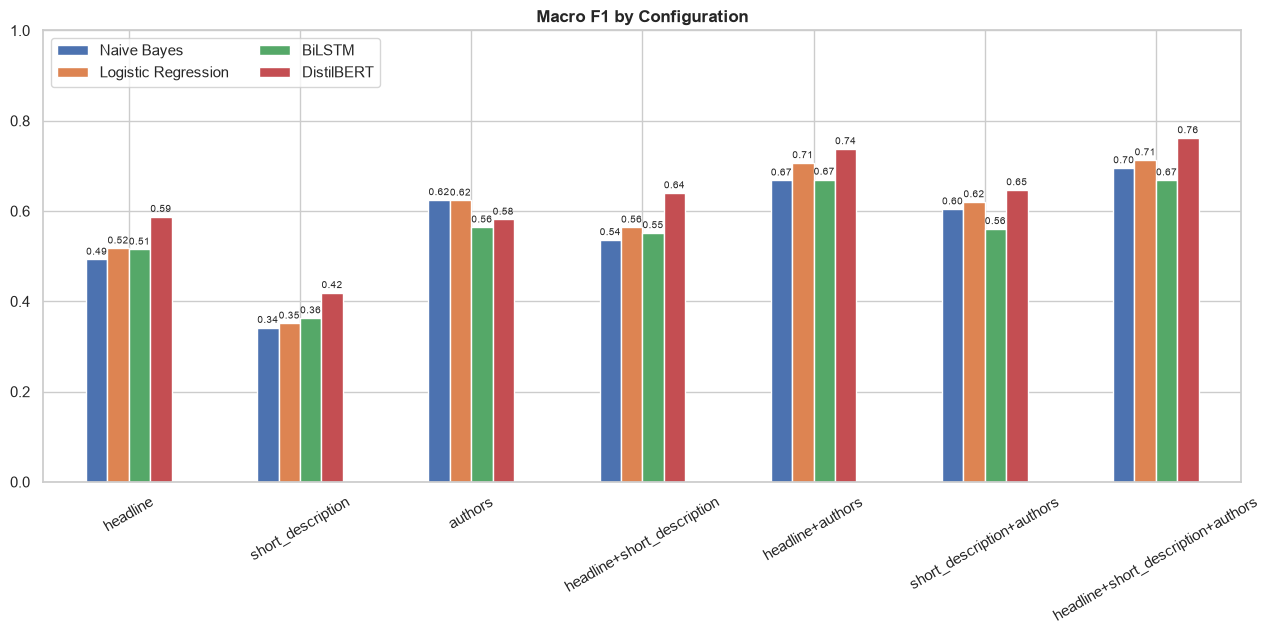

In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))
df_scores.plot.bar(ax=ax, ylim=(0, 1), rot=30, title="Macro F1 by Configuration")
for container in ax.containers:
  ax.bar_label(container, fmt="%.2f", padding=2, fontsize=7)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

#### **Winning Settings**

The hyperparameters behind each model's best configuration.


In [5]:
for model in MODELS:
  with open(DIR_IN / slug(model) / "best_params.json") as f:
    params = json.load(f)
  show(f"{model} ({best.loc[model, 'configuration']})", pd.Series(params[best.loc[model, "configuration"]]).to_frame("value"))

── Naive Bayes (headline+short_description+authors) 


,value
nb,MultinomialNB()
nb__alpha,0.1
nb__fit_prior,False
tfidf__min_df,5
tfidf__ngram_range,"[1, 2]"
tfidf__stop_words,english
tfidf__sublinear_tf,True


── Logistic Regression (headline+short_description+authors) 


,value
lr__C,10
lr__class_weight,balanced
tfidf__min_df,5
tfidf__ngram_range,"[1, 2]"
tfidf__sublinear_tf,True


── BiLSTM (headline+authors) ───────────────


,value
hidden_size,128
dropout,0.3
batch_size,64
max_epochs,30
patience,5
learning_rate,0.001
embedding,glove-wiki-gigaword-300
oov_min_freq,3


── DistilBERT (headline+short_description+authors) 


,value
checkpoint,distilbert-base-uncased
max_length,128
batch_size,64
max_epochs,12
patience,3
learning_rate,0.00005
